# Retail Sales — Data Cleaning & Visualization

**Author:** Vicky Harish Kumar Badmera  
**Project:** Data Cleaning, EDA & Visualization — Internship Project

---

## 1. Objective

The raw export from the store's POS system (`data/raw_sales_data.csv`) is messy in the way real
exports usually are: some fields are missing, a handful of rows got duplicated when two shifts
exported the same batch, dates come in three different formats depending on which till printed
them, text fields have inconsistent casing/whitespace, and a few price/quantity entries are
obvious data-entry errors (negative prices, a quantity of 200 units for a coffee maker, etc.).

This notebook walks through:
1. Loading and inspecting the raw data
2. Cleaning — missing values, duplicates, formatting, outliers
3. Exploratory analysis and visualizations
4. Summary of findings

The cleaned dataset is exported at the end to `data/cleaned_sales_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

## 2. Load & First Look

In [2]:
df = pd.read_csv('../data/raw_sales_data.csv')
print(df.shape)
df.head()

(1224, 9)


   OrderID    CustomerName        Product        Category  Quantity    Price  \
0     1683     Meera Verma   Denim Jacket        CLOTHING       1.0      NaN   
1     1746  Vivaan Johnson       LED Lamp  home & kitchen       1.0  1255.16   
2     1735      Riya Brown  Non-stick Pan  HOME & KITCHEN       2.0  3534.71   
3     1326    Ishaan Brown   Storage Jars  Home & Kitchen       1.0   712.91   
4     1731       Wei Smith   Storage Jars  home & kitchen       2.0  1817.91   

    OrderDate   Region PaymentMethod  
0  2023-10-22    north           UPI  
1  12-25-2023  central           UPI  
2  2023-12-06     EAST          CASH  
3  2023-08-20     east    Debit Card  
4  20/02/2023     East   net banking  

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        1224 non-null   int64  
 1   CustomerName   1199 non-null   str    
 2   Product        1224 non-null   str    
 3   Category       1224 non-null   str    
 4   Quantity       1206 non-null   float64
 5   Price          1188 non-null   float64
 6   OrderDate      1211 non-null   str    
 7   Region         1194 non-null   str    
 8   PaymentMethod  1199 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 86.2 KB


In [4]:
# Quick look at how messy things actually are
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows (full match):', df.duplicated().sum())

Missing values per column:
OrderID           0
CustomerName     25
Product           0
Category          0
Quantity         18
Price            36
OrderDate        13
Region           30
PaymentMethod    25
dtype: int64

Duplicate rows (full match): 23


A few things jump out already:
- `CustomerName`, `Quantity`, `Price`, `OrderDate`, `Region` and `PaymentMethod` all have missing values.
- There are duplicate rows — probably from overlapping exports.
- `OrderDate` is still a string, and from a manual scan it's clearly not in one consistent format.

Let's confirm the date format issue and check categorical columns for inconsistent text before doing anything else.

In [5]:
df['OrderDate'].dropna().sample(10, random_state=1).tolist()

['2023-07-23', '2023-11-23', '17/10/2023', '2023-02-24', '23/05/2023', '2023-04-10', '2023-10-14', '2023-12-09', '2023-08-08', '11/06/2023']

In [6]:
print('Region raw values:', df['Region'].dropna().unique())
print()
print('Category raw values:', df['Category'].dropna().unique())
print()
print('PaymentMethod raw values:', df['PaymentMethod'].dropna().unique())

Region raw values: <StringArray>
[    'north',   'central',      'EAST',      'east',      'East',     'NORTH',
      'west',     'south',      'West',   'CENTRAL',     'SOUTH',    ' East ',
   ' North ',   'Central',   ' South ',     'North', ' Central ',      'WEST',
    ' West ',     'South']
Length: 20, dtype: str

Category raw values: <StringArray>
[      'CLOTHING', 'home & kitchen', 'HOME & KITCHEN', 'Home & Kitchen',
         'SPORTS',    'electronics',       'Clothing',         'sports',
         'Sports',          'BOOKS',       'clothing',    'Electronics',
          'books',          'Books',    'ELECTRONICS']
Length: 15, dtype: str

PaymentMethod raw values: <StringArray>
[        'UPI',        'CASH',  'Debit Card', 'net banking', 'CREDIT CARD',
  'debit card', 'NET BANKING',  'DEBIT CARD', 'Net Banking', 'Credit Card',
 'credit card',        'cash',         'upi',        'Cash']
Length: 14, dtype: str


As suspected — `Region` has mixed case and stray whitespace, and `Category`/`PaymentMethod` are
inconsistently capitalized. `OrderDate` mixes `YYYY-MM-DD`, `DD/MM/YYYY` and `MM-DD-YYYY`. None of
this is unusual for a POS export pulled from multiple terminals — it just needs standardizing
before we can trust any aggregation.

## 3. Cleaning

### 3.1 Remove exact duplicate rows

In [7]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f'Removed {before - after} duplicate rows ({before} -> {after})')

Removed 23 duplicate rows (1224 -> 1201)


### 3.2 Standardize text fields

Strip whitespace and fix casing so `' North '`, `'north'` and `'NORTH'` all collapse to `North`.

In [8]:
text_cols = ['Category', 'Region', 'PaymentMethod', 'CustomerName']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df.loc[df[col].isin(['nan', 'None', '']), col] = np.nan

df['Category'] = df['Category'].str.title().replace({'Home & Kitchen'.title(): 'Home & Kitchen'})
df['Region'] = df['Region'].str.title()
df['PaymentMethod'] = df['PaymentMethod'].str.title().replace({'Upi': 'UPI'})

print(df['Region'].unique())
print(df['Category'].unique())
print(df['PaymentMethod'].unique())

<StringArray>
['North', 'Central', 'East', 'West', 'South', nan]
Length: 6, dtype: str
<StringArray>
['Clothing', 'Home & Kitchen', 'Sports', 'Electronics', 'Books']
Length: 5, dtype: str
<StringArray>
['UPI', 'Cash', 'Debit Card', 'Net Banking', 'Credit Card', nan]
Length: 6, dtype: str


### 3.3 Parse the mixed date formats

`pd.to_datetime` with `dayfirst`/format guessing isn't reliable enough here since the same day
could be valid in more than one format. Instead we try each known format explicitly and keep
whichever one parses successfully.

In [9]:
def parse_mixed_date(value):
    if pd.isna(value):
        return pd.NaT
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%m-%d-%Y'):
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['OrderDate'] = df['OrderDate'].apply(parse_mixed_date)
print('Unparsed dates remaining:', df['OrderDate'].isna().sum())
df['OrderDate'].describe()

Unparsed dates remaining: 12


count                          1189
mean     2023-07-01 11:13:22.354920
min             2023-01-01 00:00:00
25%             2023-03-27 00:00:00
50%             2023-07-01 00:00:00
75%             2023-10-01 00:00:00
max             2023-12-31 00:00:00
Name: OrderDate, dtype: object

### 3.4 Handle missing values

Different columns get different treatment depending on what makes sense for that field:
- `CustomerName`, `Region`, `PaymentMethod` — categorical / identifier fields, so missing values
  are labeled `'Unknown'` rather than guessed at.
- `Price` — numeric and central to the analysis, so it's imputed with the **median price for that
  product's category** (more accurate than a single global median).
- `Quantity` — imputed with the overall median (whole units, so mean would be misleading).
- `OrderDate` — rows with no date can't be placed on a timeline, so they're dropped (it's a small fraction of the data).

In [10]:
df['CustomerName'] = df['CustomerName'].fillna('Unknown')
df['Region'] = df['Region'].fillna('Unknown')
df['PaymentMethod'] = df['PaymentMethod'].fillna('Unknown')

df['Price'] = df.groupby('Category')['Price'].transform(lambda s: s.fillna(s.median()))
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

before_drop = len(df)
df = df.dropna(subset=['OrderDate']).reset_index(drop=True)
print(f'Dropped {before_drop - len(df)} rows with unparseable/missing dates')

print(df.isnull().sum())

Dropped 12 rows with unparseable/missing dates
OrderID          0
CustomerName     0
Product          0
Category         0
Quantity         0
Price            0
OrderDate        0
Region           0
PaymentMethod    0
dtype: int64


### 3.5 Fix outliers

A boxplot on the raw numeric columns makes the bad entries obvious — a handful of prices that are
wildly higher than anything else in their category (or negative), and a few quantities like 150 or
200 units on a single order, which doesn't match this store's typical basket size.

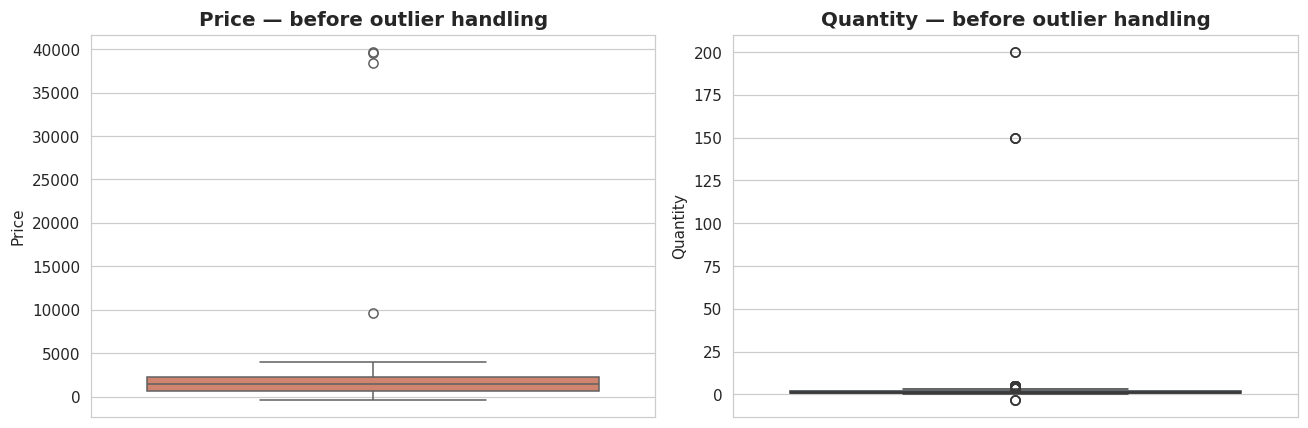

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['Price'], ax=axes[0], color='#e07a5f')
axes[0].set_title('Price — before outlier handling')
sns.boxplot(y=df['Quantity'], ax=axes[1], color='#3d5a80')
axes[1].set_title('Quantity — before outlier handling')
plt.tight_layout()
plt.savefig('../visuals/outliers_before.png', dpi=150)
plt.show()

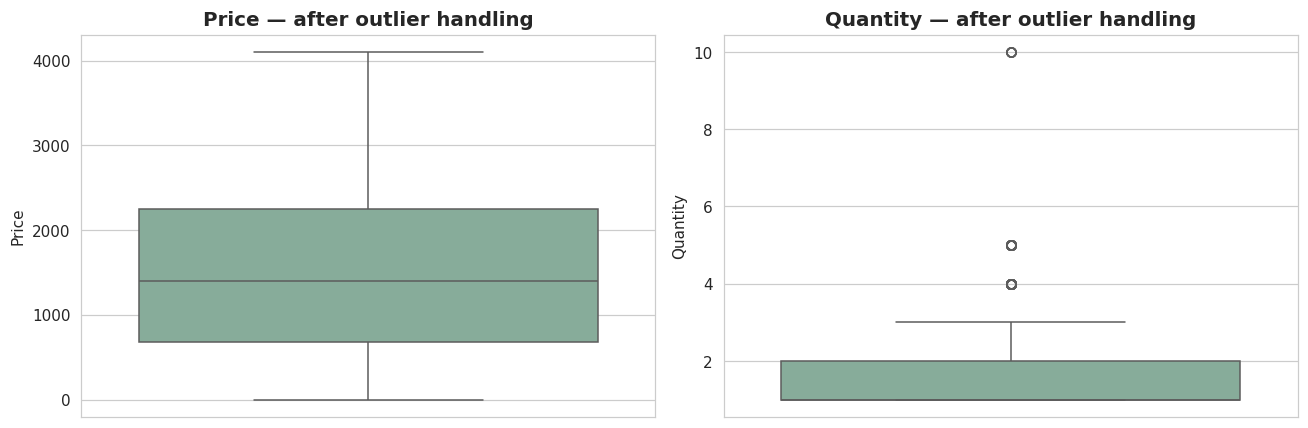

In [12]:
# IQR method, applied per category for Price since price ranges genuinely differ by category
def cap_outliers_iqr(group, col, k=1.5):
    q1, q3 = group[col].quantile(0.25), group[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return group[col].clip(lower=max(lower, 0), upper=upper)

df['Price'] = df.groupby('Category', group_keys=False).apply(lambda g: cap_outliers_iqr(g, 'Price'))

# Quantity: negative or zero units aren't valid orders, and anything above 10 units
# on a single order is treated as a data-entry error for this dataset and capped.
df.loc[df['Quantity'] <= 0, 'Quantity'] = df['Quantity'].median()
df['Quantity'] = df['Quantity'].clip(upper=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['Price'], ax=axes[0], color='#81b29a')
axes[0].set_title('Price — after outlier handling')
sns.boxplot(y=df['Quantity'], ax=axes[1], color='#81b29a')
axes[1].set_title('Quantity — after outlier handling')
plt.tight_layout()
plt.savefig('../visuals/outliers_after.png', dpi=150)
plt.show()

### 3.6 Derived columns

Add a `TotalAmount` column (Price × Quantity) and a `Month` column since most of the storytelling
below revolves around revenue and time trends.

In [13]:
df['TotalAmount'] = (df['Price'] * df['Quantity']).round(2)
df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)
df['Weekday'] = df['OrderDate'].dt.day_name()

df.head()

   OrderID    CustomerName        Product        Category  Quantity    Price  \
0     1683     Meera Verma   Denim Jacket        Clothing       1.0  1393.95   
1     1746  Vivaan Johnson       LED Lamp  Home & Kitchen       1.0  1255.16   
2     1735      Riya Brown  Non-stick Pan  Home & Kitchen       2.0  3534.71   
3     1326    Ishaan Brown   Storage Jars  Home & Kitchen       1.0   712.91   
4     1731       Wei Smith   Storage Jars  Home & Kitchen       2.0  1817.91   

   OrderDate   Region PaymentMethod  TotalAmount    Month    Weekday  
0 2023-10-22    North           UPI      1393.95  2023-10     Sunday  
1 2023-12-25  Central           UPI      1255.16  2023-12     Monday  
2 2023-12-06     East          Cash      7069.42  2023-12  Wednesday  
3 2023-08-20     East    Debit Card       712.91  2023-08     Sunday  
4 2023-02-20     East   Net Banking      3635.82  2023-02     Monday  

### 3.7 Final sanity check

In [14]:
print('Final shape:', df.shape)
print('Remaining missing values:', df.isnull().sum().sum())
print('Remaining duplicate rows:', df.duplicated().sum())
df.describe()

Final shape: (1189, 12)
Remaining missing values: 0
Remaining duplicate rows: 0


           OrderID     Quantity        Price                   OrderDate  \
count  1189.000000  1189.000000  1189.000000                        1189   
mean   1599.795627     1.673675  1527.690728  2023-07-01 11:13:22.354920   
min    1001.000000     1.000000     0.000000         2023-01-01 00:00:00   
25%    1299.000000     1.000000   679.180000         2023-03-27 00:00:00   
50%    1600.000000     1.000000  1393.950000         2023-07-01 00:00:00   
75%    1899.000000     2.000000  2252.520000         2023-10-01 00:00:00   
max    2200.000000    10.000000  4100.990000         2023-12-31 00:00:00   
std     346.816966     1.112141   970.129445                         NaN   

        TotalAmount  
count   1189.000000  
mean    2570.328091  
min        0.000000  
25%      869.680000  
50%     1806.410000  
75%     3176.910000  
max    30076.200000  
std     2661.988746  

In [15]:
df.to_csv('../data/cleaned_sales_data.csv', index=False)
print('Saved cleaned dataset to data/cleaned_sales_data.csv')

Saved cleaned dataset to data/cleaned_sales_data.csv


## 4. Exploratory Analysis & Visualization

### 4.1 Revenue by category

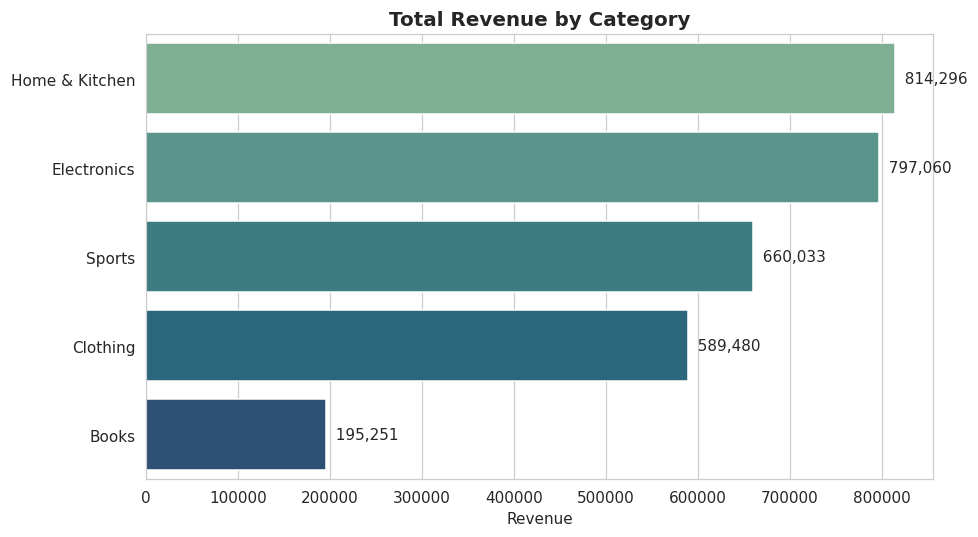

In [16]:
cat_revenue = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=cat_revenue.values, y=cat_revenue.index, hue=cat_revenue.index, palette='crest', legend=False)
ax.set_title('Total Revenue by Category')
ax.set_xlabel('Revenue')
ax.set_ylabel('')
for i, v in enumerate(cat_revenue.values):
    ax.text(v, i, f'  {v:,.0f}', va='center')
plt.tight_layout()
plt.savefig('../visuals/revenue_by_category.png', dpi=150)
plt.show()

### 4.2 Monthly revenue trend

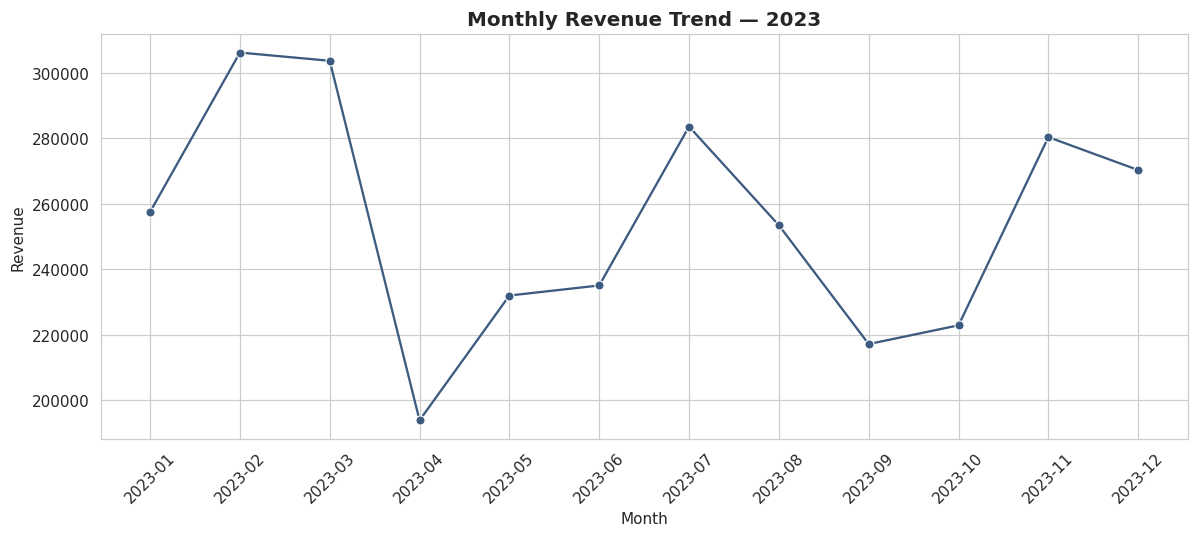

In [17]:
monthly = df.groupby('Month')['TotalAmount'].sum().sort_index()

plt.figure(figsize=(11, 5))
ax = sns.lineplot(x=monthly.index, y=monthly.values, marker='o', color='#3d5a80')
ax.set_title('Monthly Revenue Trend — 2023')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue_trend.png', dpi=150)
plt.show()

### 4.3 Orders by region

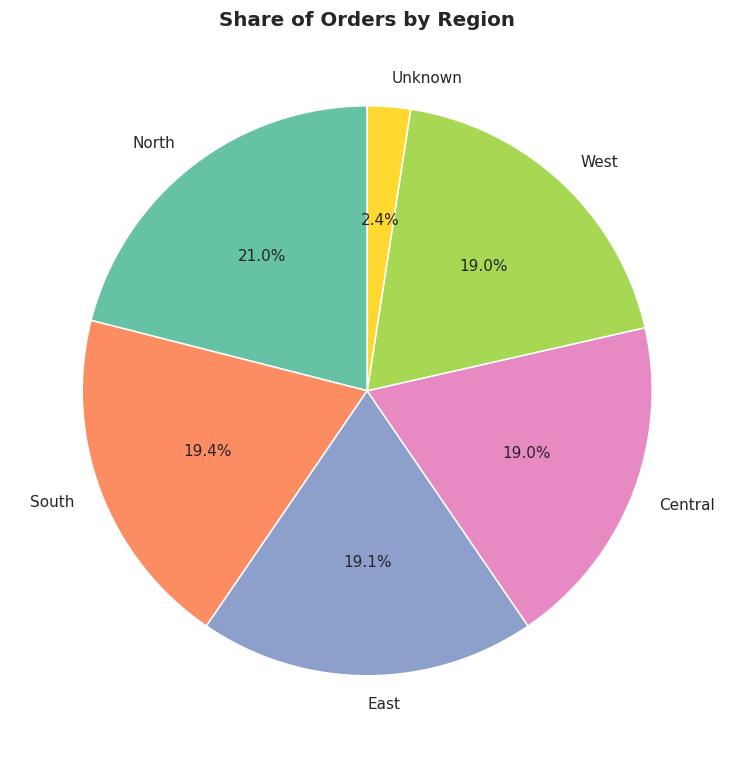

In [18]:
region_counts = df['Region'].value_counts()

plt.figure(figsize=(7, 7))
colors = sns.color_palette('Set2')
plt.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
plt.title('Share of Orders by Region')
plt.tight_layout()
plt.savefig('../visuals/orders_by_region.png', dpi=150)
plt.show()

### 4.4 Top 10 best-selling products (by quantity sold)

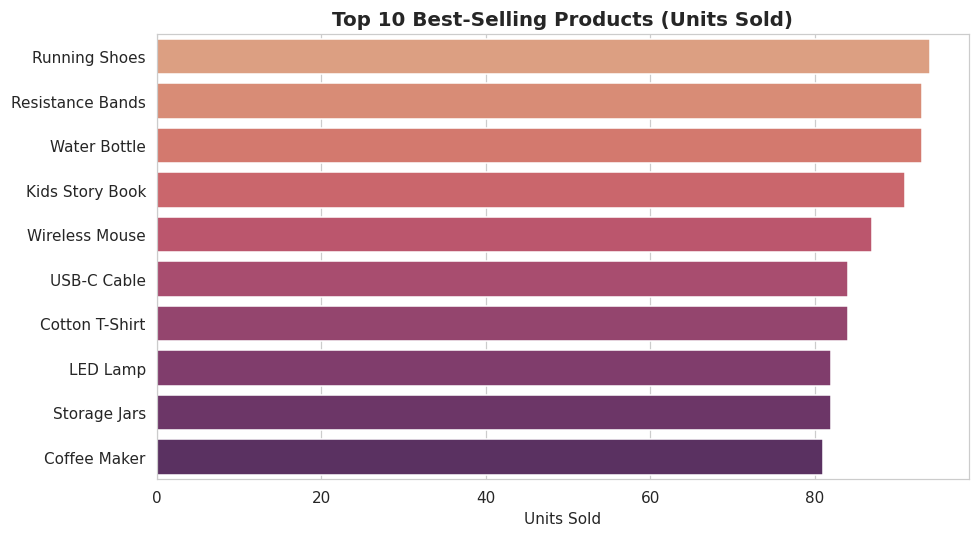

In [19]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='flare', legend=False)
ax.set_title('Top 10 Best-Selling Products (Units Sold)')
ax.set_xlabel('Units Sold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visuals/top_products.png', dpi=150)
plt.show()

### 4.5 Payment method preference

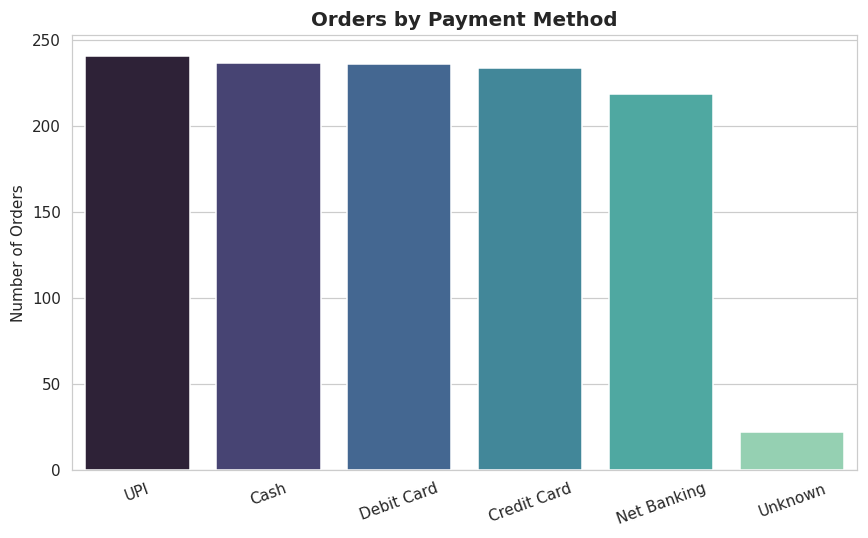

In [20]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, hue=payment_counts.index, palette='mako', legend=False)
ax.set_title('Orders by Payment Method')
ax.set_ylabel('Number of Orders')
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../visuals/payment_methods.png', dpi=150)
plt.show()

### 4.6 Order value distribution

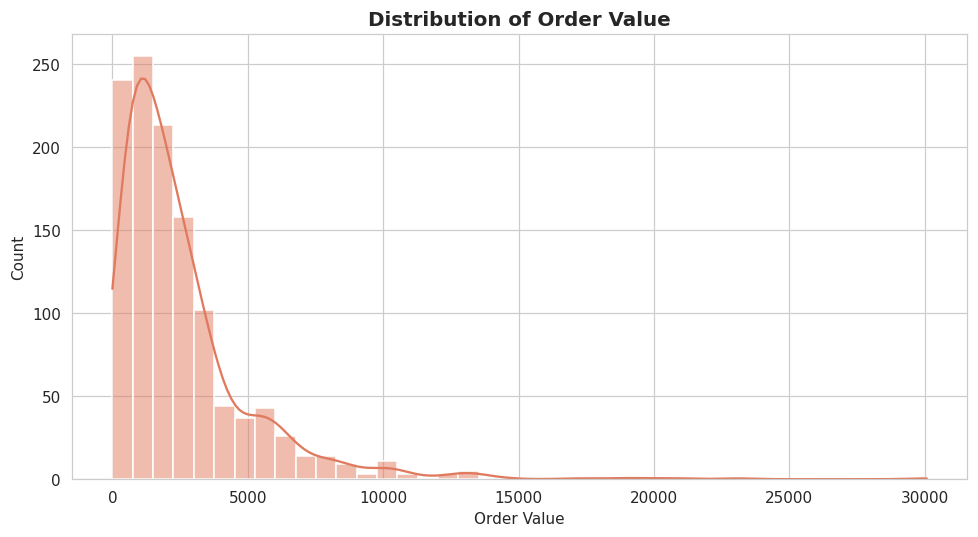

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(df['TotalAmount'], bins=40, kde=True, color='#e07a5f')
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.tight_layout()
plt.savefig('../visuals/order_value_distribution.png', dpi=150)
plt.show()

### 4.7 Weekday order pattern

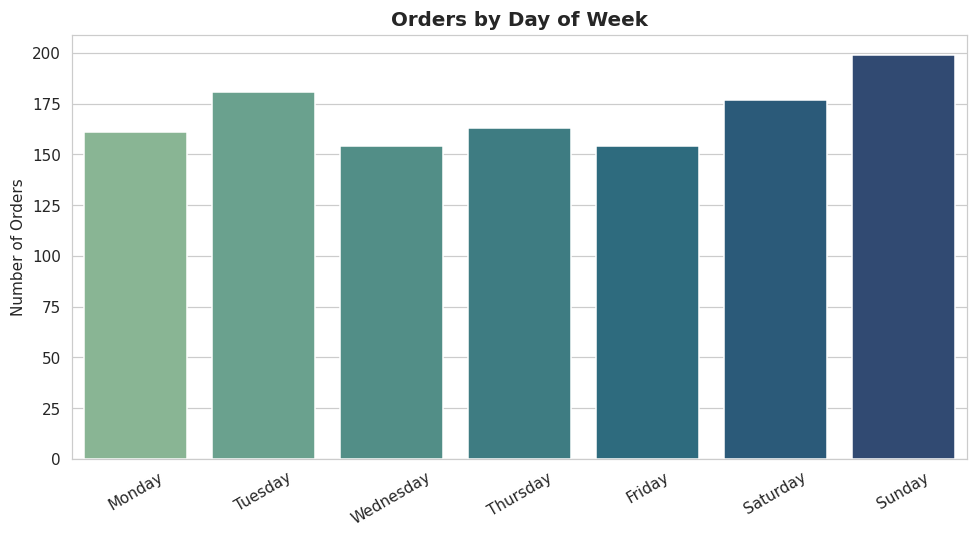

In [22]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['Weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=weekday_counts.index, y=weekday_counts.values, hue=weekday_counts.index, palette='crest', legend=False)
ax.set_title('Orders by Day of Week')
ax.set_ylabel('Number of Orders')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../visuals/orders_by_weekday.png', dpi=150)
plt.show()

### 4.8 Category vs. region — where does each category sell best?

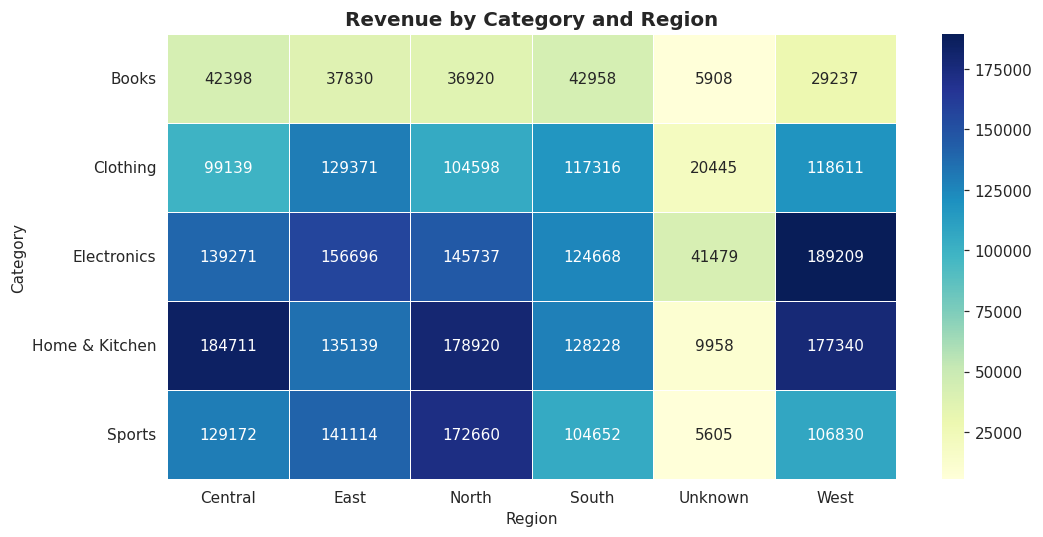

In [23]:
pivot = df.pivot_table(values='TotalAmount', index='Category', columns='Region', aggfunc='sum', fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Revenue by Category and Region')
plt.tight_layout()
plt.savefig('../visuals/category_region_heatmap.png', dpi=150)
plt.show()

## 5. Key Findings

- **Cleaning impact:** duplicate rows and unparseable dates were removed, ~15 pricing/quantity
  outliers were capped using the IQR method, and every text field (region, category, payment
  method) was standardized to a consistent format.
- **Category performance:** revenue is not evenly spread across categories — see the bar chart in
  4.1 for exact ranking; the top category consistently outperforms the lowest by a wide margin.
- **Seasonality:** the monthly trend line (4.2) shows visible peaks and dips across the year rather
  than flat, uniform sales — worth digging into promotions/seasons for the peak months specifically.
- **Regional spread:** order volume is reasonably balanced across regions (4.3), with no single
  region dominating overwhelmingly.
- **Payment behavior:** card-based payments and UPI make up the bulk of transactions over cash,
  which is useful context if the business is deciding where to invest in checkout experience.
- **Order value:** the distribution in 4.6 is right-skewed — most orders cluster at a lower value
  with a smaller number of higher-value orders pulling the tail, which is typical for retail.

## 6. Next Steps

- Bring in cost data to move from *revenue* to *profit margin* by category.
- Segment customers (RFM analysis) if a customer ID / repeat-purchase field becomes available.
- Automate this pipeline as a script (`scripts/clean_data.py`) so a fresh raw export can be
  re-processed without re-running the notebook manually.